In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("subhajournal/phishingemails")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\jeffr\.cache\kagglehub\datasets\subhajournal\phishingemails\versions\1


In [3]:
import pandas as pd
df = pd.read_csv(path + "/Phishing_Email.csv")
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
len(df)

18650

In [5]:
replacements = {"Safe Email" : 1, "Phishing Email" : 0}
df = df.replace({"Email Type": replacements})
df.head()

C:\Users\jeffr\AppData\Local\Temp\ipykernel_28284\701235505.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"Email Type": replacements})


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",1
1,1,the other side of * galicismos * * galicismo *...,1
2,2,re : equistar deal tickets are you still avail...,1
3,3,\nHello I am your hot lil horny toy.\n I am...,0
4,4,software at incredibly low prices ( 86 % lower...,0


In [6]:
df = df.dropna()

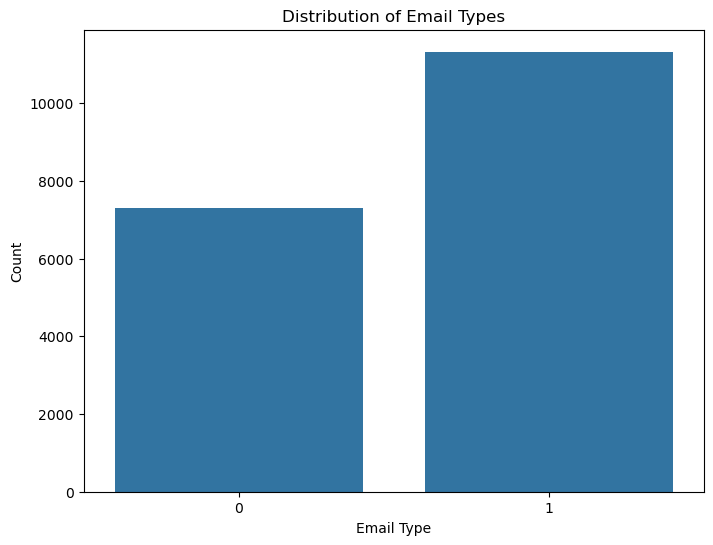

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Email Type', data=df)
plt.title('Distribution of Email Types')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.show()

In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [9]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jeffr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jeffr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jeffr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [11]:
def clean_email_text(text):
    # Remove non-alphabetic characters and lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

In [12]:
df['Email Text'] = df['Email Text'].apply(clean_email_text)

In [13]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

c:\Users\jeffr\.conda\envs\pytorch_env\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\jeffr\.conda\envs\pytorch_env\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [14]:
MODEL_NAME = "roberta-base"
MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EPOCHS = 3
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
SEED = 42

In [15]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
print("Device:", DEVICE)

Device: cuda


In [16]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["Email Type"],
    random_state=SEED
)

In [17]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [18]:
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

c:\Users\jeffr\.conda\envs\pytorch_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


: 

In [149]:
class PhishingDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["Email Text"].tolist()
        self.labels = dataframe["Email Type"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        
        # 1. Just get the raw IDs without any fancy arguments
        tokens = tokenizer.encode(text, add_special_tokens=True)
        
        # 2. Manual Truncation
        if len(tokens) > MAX_LENGTH:
            tokens = tokens[:MAX_LENGTH]
            
        # 3. Manual Padding
        padding_length = MAX_LENGTH - len(tokens)
        attention_mask = [1] * len(tokens)
        
        if padding_length > 0:
            tokens = tokens + [tokenizer.pad_token_id] * padding_length
            attention_mask = attention_mask + [0] * padding_length

        return {
            "input_ids": torch.tensor(tokens, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "Email Type": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [150]:
def collate_fn(batch):
    input_ids = [x["input_ids"] for x in batch]
    attention_mask = [x["attention_mask"] for x in batch]
    labels = torch.stack([x["Email Type"] for x in batch])

    input_ids = torch.nn.utils.rnn.pad_sequence(
        input_ids,
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )

    attention_mask = torch.nn.utils.rnn.pad_sequence(
        attention_mask,
        batch_first=True,
        padding_value=0
    )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "Email Type": labels,
    }

In [151]:
train_loader = DataLoader(
    PhishingDataset(train_df),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

In [152]:
val_loader = DataLoader(
    PhishingDataset(val_df),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [153]:
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)
model.to(DEVICE)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [154]:
counts = train_df["Email Type"].value_counts().sort_index().values
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = weights / weights.sum()

loss_fn = torch.nn.CrossEntropyLoss(weight=weights.to(DEVICE))

In [155]:
optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    return max(
        0.0,
        (total_steps - step) / max(1, total_steps - warmup_steps)
    )

scheduler = LambdaLR(optimizer, lr_lambda)

In [162]:
def train_epoch():
    model.train()
    total_loss = 0

    for batch in train_loader:
        # Move everything to GPU/CPU
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        # FIX 1: Handle the 'tuple' vs 'attribute' issue
        # If outputs is a tuple, logits is the first element. Otherwise, use .logits
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs.logits

        # FIX 2: Use the key "labels" to match your collate_fn/Dataset return
        # (Assuming your collate_fn still names it "labels")
        loss = loss_fn(logits, batch["Email Type"]) 
        
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [163]:
def evaluate():
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            logits = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"]
            ).logits

            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            labels.extend(batch["Email Type"].cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    return precision, recall, f1


In [164]:
best_f1 = 0.0

for epoch in range(EPOCHS):
    loss = train_epoch()
    p, r, f1 = evaluate()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss {loss:.4f} | "
        f"P {p:.4f} | R {r:.4f} | F1 {f1:.4f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        model.save_pretrained("roberta-phishing")
        tokenizer.save_pretrained("roberta-phishing")

print("Training complete. Best F1:", best_f1)

Token indices sequence length is longer than the specified maximum sequence length for this model (546 > 512). Running this sequence through the model will result in indexing errors


Token indices sequence length is longer than the specified maximum sequence length for this model (933 > 512). Running this sequence through the model will result in indexing errors


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
